<a href="https://colab.research.google.com/github/mersalas/ecosa/blob/main/ecoli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Install packages**

In [1]:
# Must install the following packages in python 3.8
#!pip install deep-forest
#!pip install pyforest
#!pip install umap-learn
#!pip install scikit-optimize
#!pip install shap

#**Load dataset**

In [2]:
# Import the necessary libraries
from pyforest import*
lazy_imports() # load most libraries
import deepchem as dc
from rdkit import Chem
import random, umap, warnings, time, joblib
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from skopt import BayesSearchCV
from datetime import timedelta
from skopt.plots import plot_objective
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from deepforest import CascadeForestClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, auc, roc_auc_score, matthews_corrcoef, classification_report # evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve # plots
import shap # feature importance

2024-10-01 09:01:48.752446: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-01 09:01:48.775759: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-01 09:01:49.118465: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [3]:
# Loading the dataset
url = 'https://raw.githubusercontent.com/mersalas/ecosa/main/dataset/Eco_res.csv'
df = pd.read_csv(url)
y = df.iloc[:, 4].values
df.head()

<IPython.core.display.Javascript object>

,id,length,moa,smiles,Ecoli
0,11,26,lipid bilayer,O=C(N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@@H...,1
1,15,24,lipid bilayer,[NH3+]CCCC[C@H](NC(=O)[C@@H](NC(=O)[C@H](CCCC[...,0
2,127,20,lipid bilayer,O=C(N[C@@H](CC(C)C)C(=O)N[C@@H](CCCNC(N)=[NH2+...,0
3,128,20,lipid bilayer,O=C(N[C@@H](CCCC[NH3+])C(=O)N[C@@H](CCCC[NH3+]...,0
4,144,13,lipid bilayer,C[C@@H](CC)[C@H](NC(=O)[C@H](CCCNC(=[NH2+])N)N...,1


In [4]:
# Function to calculate the total charge and fraction of C-C pairs
def calculate_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    
    # calculate the total charge
    Q = sum([atom.GetFormalCharge() for atom in mol.GetAtoms()])
    
    # calculate the fraction of C-C pairs
    num_bonds = mol.GetNumBonds()
    num_cc_pairs = sum(1 for bond in mol.GetBonds() if bond.GetBeginAtom().GetSymbol() == 'C' and bond.GetEndAtom().GetSymbol() == 'C')
    frac_CC = num_cc_pairs / num_bonds if num_bonds > 0 else 0
    
    return Q, frac_CC

In [5]:
# Apply the function to each SMILES string in the DataFrame
properties = df['smiles'].apply(calculate_properties)
df['Q'], df['frac_CC'] = zip(*properties)

# Scale Q and fra_CC pairs columns
scaler_qc = RobustScaler()
df[['Q', 'frac_CC']] = scaler_qc.fit_transform(df[['Q', 'frac_CC']])

In [6]:
# Featurize smiles
tasks = ['Ecoli']
featurizer = dc.feat.CircularFingerprint(radius=5, size=1024, chiral=True, bonds=True,
                                        features=True, is_counts_based=True)

loader = dc.data.CSVLoader(tasks=tasks, feature_field='smiles', featurizer=featurizer)
dataset = loader.create_dataset(url)

In [7]:
# Scale ECFPs columns
scaler_ecfp = RobustScaler()
ecfp_scale = scaler_ecfp.fit_transform(dataset.X)

# Convert dataset.X to DataFrame
ecfp = pd.DataFrame(ecfp_scale)
col = ['ECFP' + str(x) for x in range(0,1024)]
ecfp.columns = col

<IPython.core.display.Javascript object>

In [8]:
# Concatenate Q & frac_CC columns with the ECFPs
X = pd.concat([df[['Q', 'frac_CC']], ecfp], axis=1)
X.head()

<IPython.core.display.Javascript object>

,Q,frac_CC,ECFP0,ECFP1,ECFP2,ECFP3,ECFP4,ECFP5,ECFP6,ECFP7,...,ECFP1014,ECFP1015,ECFP1016,ECFP1017,ECFP1018,ECFP1019,ECFP1020,ECFP1021,ECFP1022,ECFP1023
0,1.333333,-0.092398,1.525,1.181818,1.307692,1.0,0.533333,0.0,0.0,0.0,...,0.0,0.0,1.3,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.333333,-1.314877,0.550,1.000000,1.307692,1.5,1.800000,3.0,7.0,0.0,...,0.0,3.0,0.9,2.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.000000,-0.671702,1.050,0.363636,1.230769,-0.5,-0.800000,-0.5,0.0,0.0,...,2.0,-0.5,0.6,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,2.666667,-0.422293,0.975,0.545455,1.384615,-0.5,-0.400000,-0.5,0.0,0.0,...,1.0,-0.5,0.6,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.000000,-0.039352,-0.075,-0.090909,0.230769,0.5,0.000000,-0.5,0.0,0.0,...,0.0,-0.5,-0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Normalize the data
normalizer = MinMaxScaler()
X_norm = normalizer.fit_transform(X)

# Convert X_norm into DataFrame
X_norm = pd.DataFrame(X_norm, columns=X.columns)
print(X_norm.shape)
X_norm.head()

<IPython.core.display.Javascript object>

(2652, 1026)


,Q,frac_CC,ECFP0,ECFP1,ECFP2,ECFP3,ECFP4,ECFP5,ECFP6,ECFP7,...,ECFP1014,ECFP1015,ECFP1016,ECFP1017,ECFP1018,ECFP1019,ECFP1020,ECFP1021,ECFP1022,ECFP1023
0,0.500000,0.414846,0.746914,0.710526,0.614035,0.250000,0.217391,0.05,0.00,0.0,...,0.000000,0.05,0.78125,0.1,0.0,0.333333,0.000000,0.0,0.0,0.00
1,0.384615,0.212408,0.506173,0.657895,0.614035,0.333333,0.423913,0.35,0.35,0.0,...,0.000000,0.35,0.65625,0.2,0.0,0.000000,0.000000,0.0,0.0,0.25
2,0.576923,0.318915,0.629630,0.473684,0.596491,0.000000,0.000000,0.00,0.00,0.0,...,0.333333,0.00,0.56250,0.0,0.5,0.000000,0.142857,0.0,0.0,0.00
3,0.653846,0.360217,0.611111,0.526316,0.631579,0.000000,0.065217,0.00,0.00,0.0,...,0.166667,0.00,0.56250,0.0,0.5,0.000000,0.142857,0.0,0.0,0.00
4,0.346154,0.423631,0.351852,0.342105,0.368421,0.166667,0.130435,0.00,0.00,0.0,...,0.000000,0.00,0.34375,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00


In [10]:
# Check missing or null values
print(f'There are {pd.concat([X_norm], axis=1).isnull().sum().sum()} missing values \n')

# Count target
print(f'AMP: {df["Ecoli"].value_counts()[1]}, non-AMP: {df["Ecoli"].value_counts()[0]}')

<IPython.core.display.Javascript object>

There are 0 missing values 

AMP: 1326, non-AMP: 1326


In [11]:
# Generate a random integer to use in random_state
random_state=42
#random_state = random.randint(0, 10000)
print(random_state)

42


#**UMAP**

In [12]:
# Extract the charge feature
QC = X_norm[['Q', 'frac_CC']]
QC.head()

,Q,frac_CC
0,0.500000,0.414846
1,0.384615,0.212408
2,0.576923,0.318915
3,0.653846,0.360217
4,0.346154,0.423631


In [13]:
# Initialize UMAP 
reducer = umap.UMAP(n_neighbors=15, min_dist=0.8, n_components=2, 
                    metric='manhattan', random_state=random_state)

# Fit transform
X_umap = reducer.fit_transform(QC)

print(X_umap.shape)

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


(2652, 2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

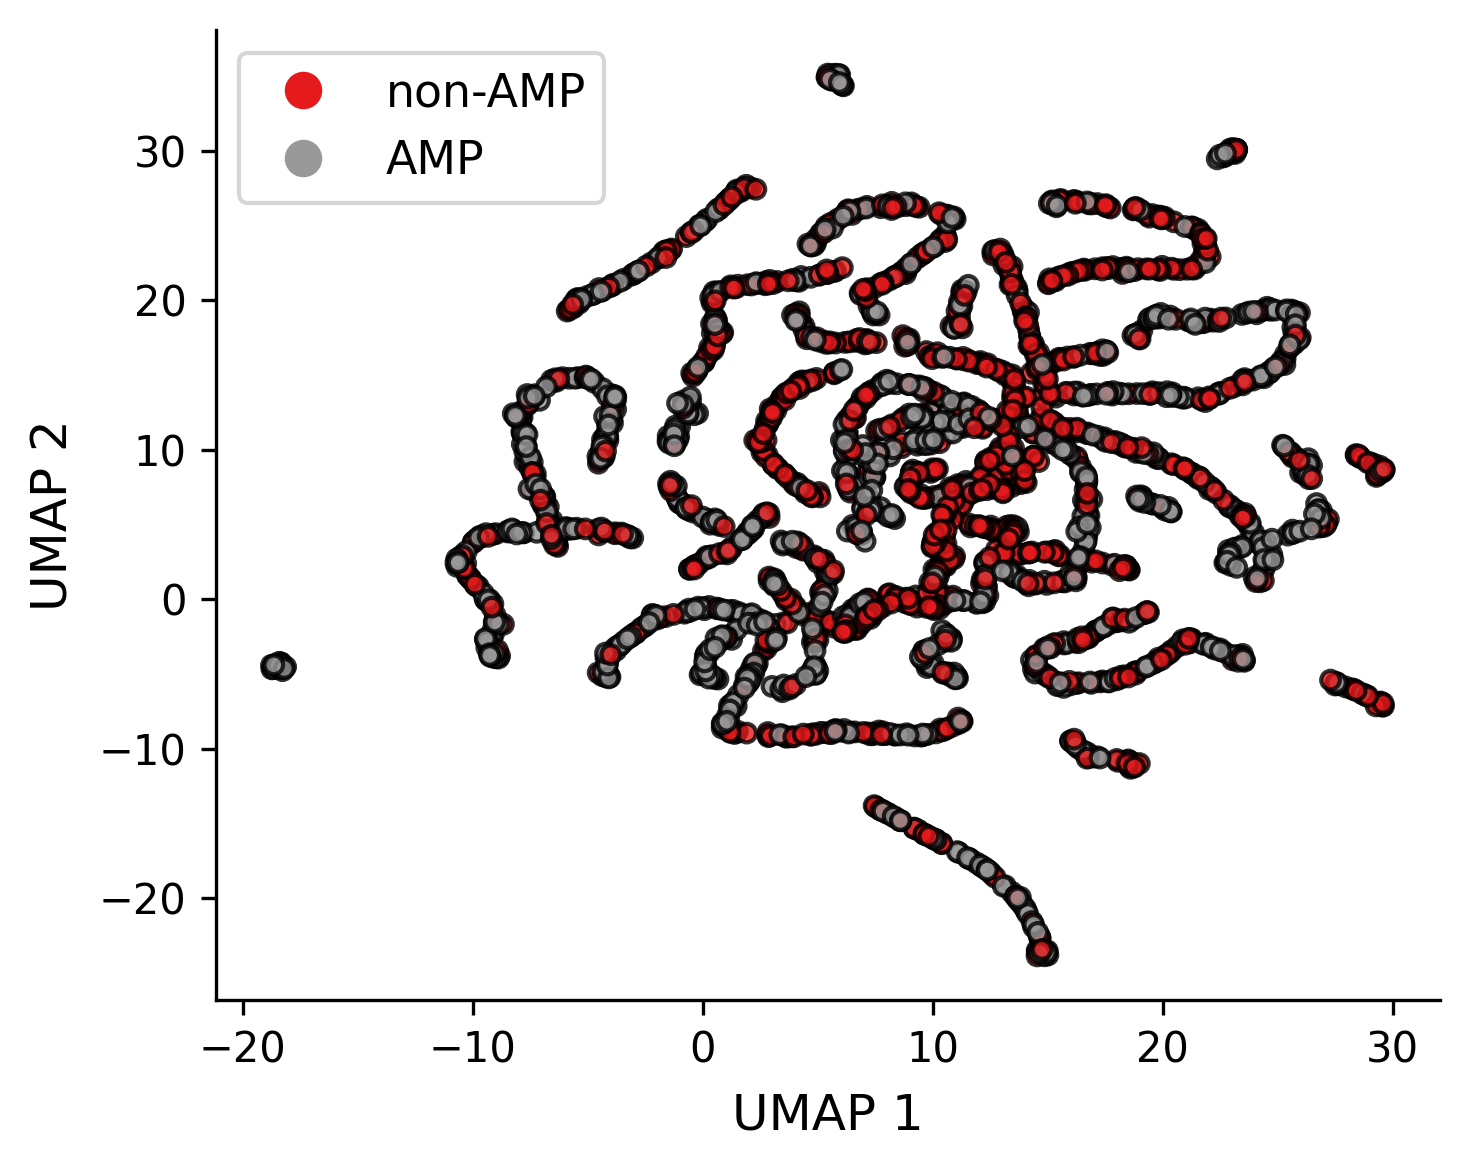

In [14]:
# AMP labels
unique_labels = np.unique(y)
label_names = ['non-AMP', 'AMP']

# 2D UMAP plot
plt.figure(figsize=(5, 4), dpi=300)
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=y, cmap='Set1', s=20, edgecolor='k', alpha=0.8)

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(i / (len(unique_labels) - 1)), markersize=10, label=label_names[i])
           for i in unique_labels]
plt.legend(handles=handles, fontsize=11, loc='best')

# Set coordinate labels
plt.xlabel('UMAP 1', fontsize=12, labelpad=5)
plt.ylabel('UMAP 2', fontsize=12, labelpad=5)

# Clean up the plot
plt.grid(False)
sns.despine()
plt.tight_layout()

# Save the plot 
# plt.savefig('Eco_UMAP.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Extract the ECFP features
ECFP = X_norm.drop(columns=['Q', 'frac_CC'])
ECFP.head()

,ECFP0,ECFP1,ECFP2,ECFP3,ECFP4,ECFP5,ECFP6,ECFP7,ECFP8,ECFP9,...,ECFP1014,ECFP1015,ECFP1016,ECFP1017,ECFP1018,ECFP1019,ECFP1020,ECFP1021,ECFP1022,ECFP1023
0,0.746914,0.710526,0.614035,0.250000,0.217391,0.05,0.00,0.0,0.0,0.0,...,0.000000,0.05,0.78125,0.1,0.0,0.333333,0.000000,0.0,0.0,0.00
1,0.506173,0.657895,0.614035,0.333333,0.423913,0.35,0.35,0.0,0.0,0.0,...,0.000000,0.35,0.65625,0.2,0.0,0.000000,0.000000,0.0,0.0,0.25
2,0.629630,0.473684,0.596491,0.000000,0.000000,0.00,0.00,0.0,0.0,0.0,...,0.333333,0.00,0.56250,0.0,0.5,0.000000,0.142857,0.0,0.0,0.00
3,0.611111,0.526316,0.631579,0.000000,0.065217,0.00,0.00,0.0,0.0,0.0,...,0.166667,0.00,0.56250,0.0,0.5,0.000000,0.142857,0.0,0.0,0.00
4,0.351852,0.342105,0.368421,0.166667,0.130435,0.00,0.00,0.0,0.0,0.0,...,0.000000,0.00,0.34375,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00


In [16]:
# Initialize UMAP 
reducer = umap.UMAP(n_neighbors=15, min_dist=0.8, n_components=2, 
                    metric='manhattan', random_state=random_state)

# Fit transform
X_umap = reducer.fit_transform(ECFP)

print(X_umap.shape)

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(2652, 2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

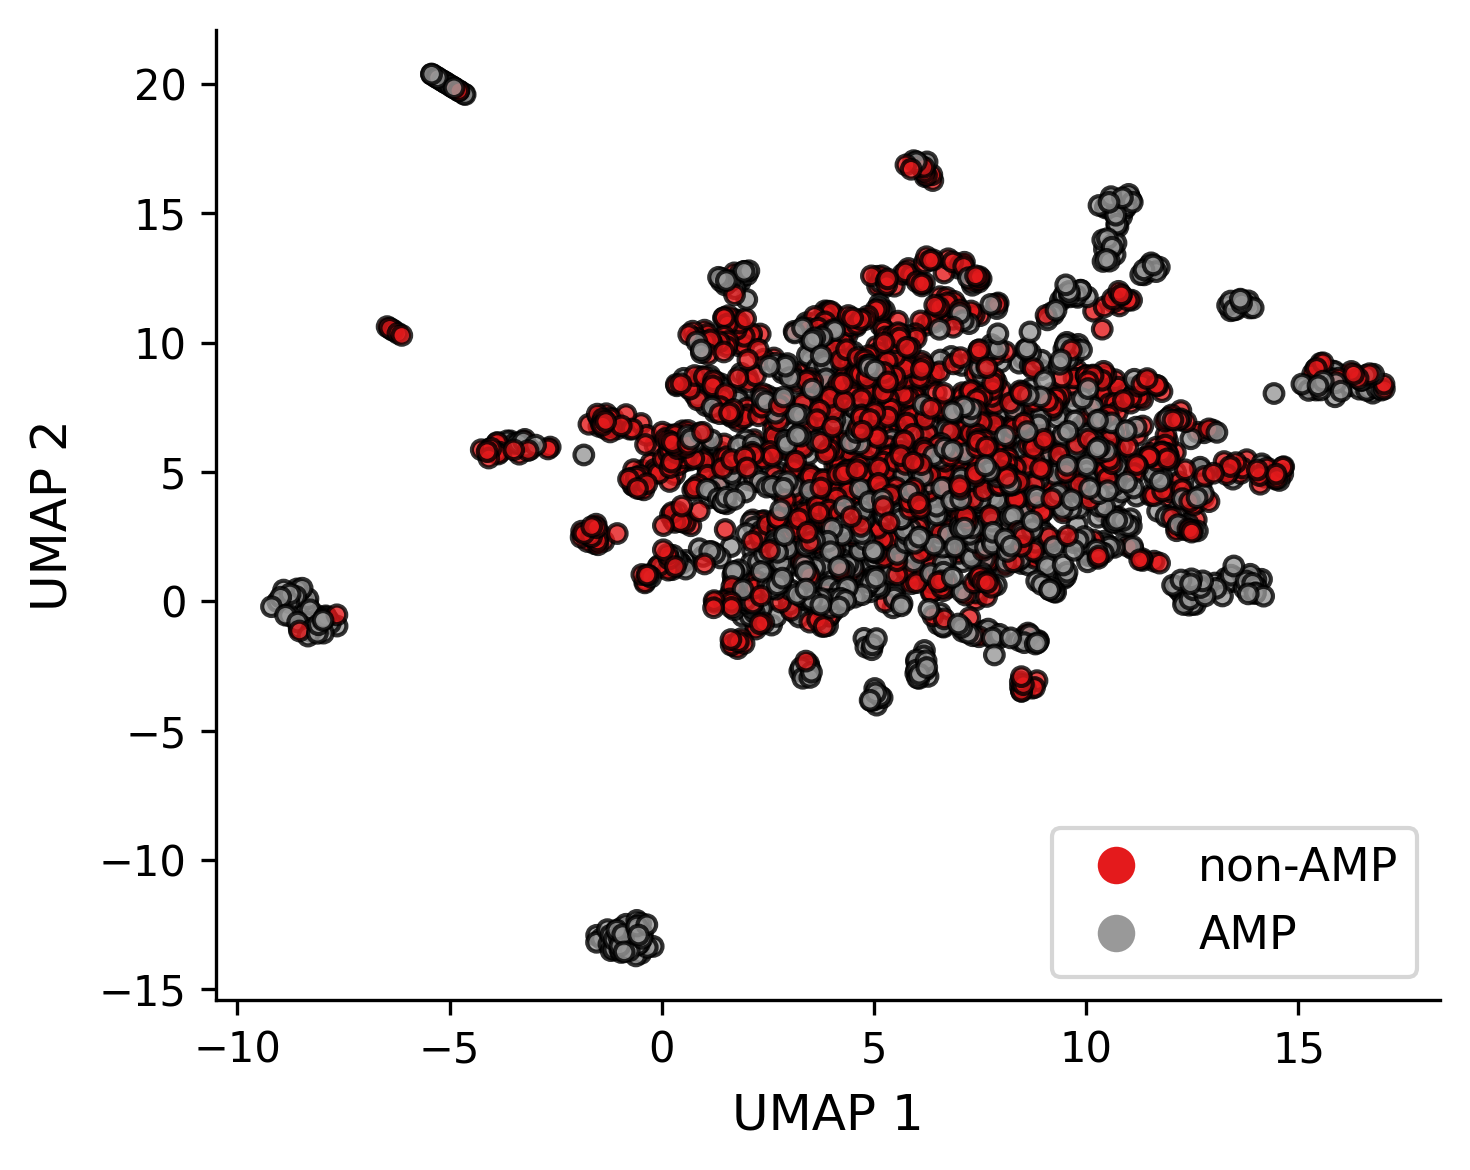

In [17]:
# 2D UMAP plot
plt.figure(figsize=(5, 4), dpi=300)
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=y, cmap='Set1', s=20, edgecolor='k', alpha=0.8)

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Set1(i / (len(unique_labels) - 1)), markersize=10, label=label_names[i])
           for i in unique_labels]
plt.legend(handles=handles, fontsize=11, loc='best')

# Set coordinate labels
plt.xlabel('UMAP 1', fontsize=12, labelpad=5)
plt.ylabel('UMAP 2', fontsize=12, labelpad=5)

# Clean up the plot
plt.grid(False)
sns.despine()
plt.tight_layout()

plt.show()

In [18]:
# Split dataset into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.15, stratify=y,
                                                   random_state=random_state)

print("Size of training set: {}   size of test set:"
      " {}\n".format(X_train.shape[0], X_test.shape[0]))

<IPython.core.display.Javascript object>

Size of training set: 2254   size of test set: 398



#**Logit**

In [19]:
# Performing Bayesian search to optimize parameters for logit
logit = LogisticRegression(max_iter=5000, random_state=random_state)

param = {'C': (1e-1,1e1, 'log-uniform')} 

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
logit_cv = BayesSearchCV(estimator=logit, search_spaces=param, cv=cv, scoring='roc_auc', 
                         n_jobs=-1, random_state=random_state)

start_time = time.time()
logit_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', logit_cv.best_params_)
print('best score after search cv:', logit_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('C', 0.473375068822139)])
best score after search cv: 0.8746559748498036
time taken: 0:01:02.509146


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

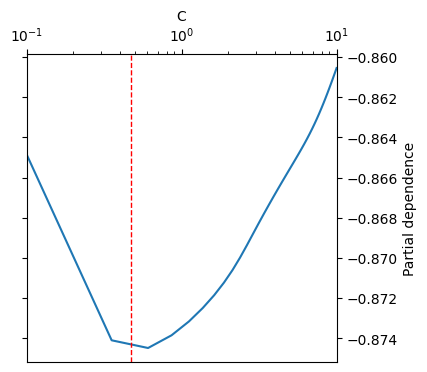

In [20]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(4, 4))
plot_objective(logit_cv.optimizer_results_[0], ax=ax)
plt.show()

In [21]:
# Train logit
logit_tuned = LogisticRegression(**logit_cv.best_params_, max_iter=5000,
                                 n_jobs=-1, random_state=random_state)

logit_tuned.fit(X_train, y_train)

<IPython.core.display.Javascript object>

LogisticRegression(C=0.473375068822139, max_iter=5000, n_jobs=-1,
                   random_state=42)

In [22]:
# Print intercept & coefficients
print('intercept:', logit_tuned.intercept_)
print('coef:', logit_tuned.coef_, end='\n')

intercept: [-3.67203767]
coef: [[ 0.82044797  1.25088108  0.38492608 ... -0.4120862   0.57168053
  -0.33440609]]


In [23]:
# Evaluate the logit model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(logit_tuned, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the logit model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the logit model on the training set:
Acc: 0.8053
Pr: 0.8037
Sn: 0.8134
F1: 0.8062
MCC: 0.6110
AUROC: 0.8770


In [24]:
# Evaluate the logit model on the test set
y_pred_logit = logit_tuned.predict(X_test)
y_proba_logit = logit_tuned.predict_proba(X_test)[:, 1]

print("Performance of the logit model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_logit)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_logit)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_logit)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_logit)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_logit)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_logit)))

Performance of the logit model on the test set:
Acc: 0.8015
Pr: 0.7970
Sn: 0.8090
F1: 0.8030
MCC: 0.6031
AUROC: 0.8645


#**KNN**

In [25]:
# Performing Bayesian search to optimize parameters for KNN
knn = KNeighborsClassifier()

param = {'n_neighbors': (3,20),
         'weights': ['distance', 'uniform'],
         'p': (1,2,3),
         'metric': ['minkowski', 'manhattan', 'euclidean']
         }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
knn_cv = BayesSearchCV(estimator=knn, search_spaces=param, cv=cv, scoring='roc_auc', 
                       n_jobs=-1, random_state=random_state)

start_time = time.time()
knn_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', knn_cv.best_params_)
print('best score after search cv:', knn_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('metric', 'manhattan'), ('n_neighbors', 9), ('p', 2), ('weights', 'distance')])
best score after search cv: 0.8905667884273296
time taken: 0:00:57.541418


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

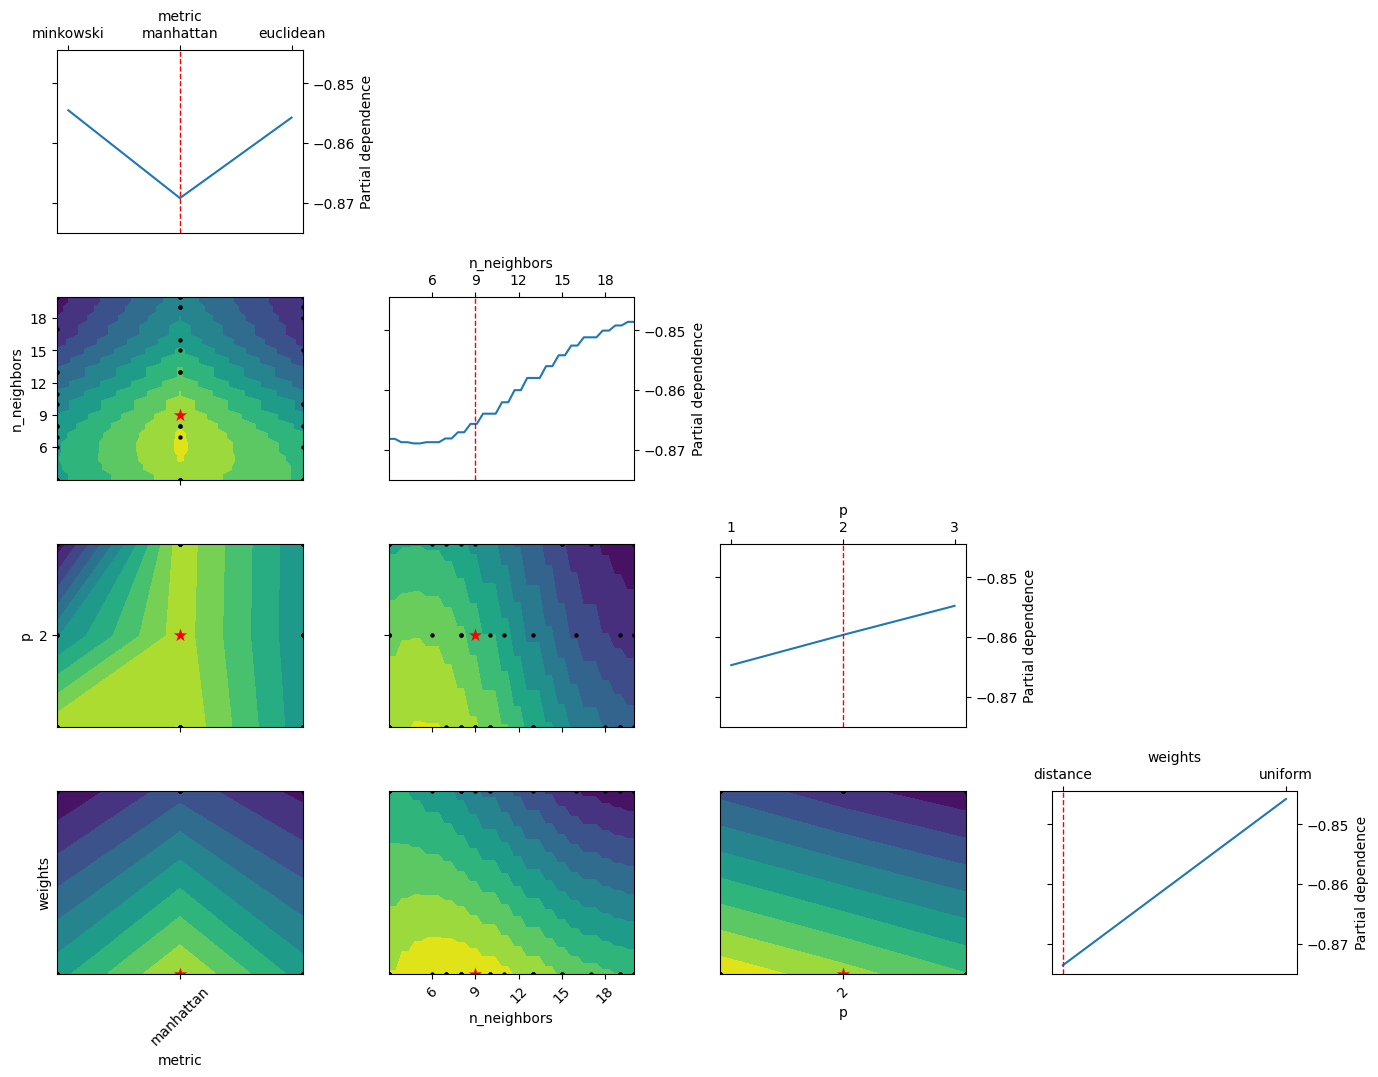

In [26]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(16, 12))
plot_objective(knn_cv.optimizer_results_[0], ax=ax)
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

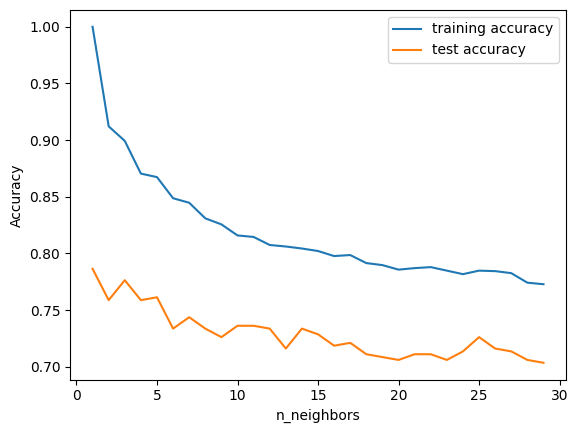

In [27]:
# Find the optimum k
train_acc = []
test_acc = []

# try n_neighbors from 1 to 30
neighbors_settings = range(1, 30)

for n_neighbors in neighbors_settings:
    # build the model
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    
    # record training set accuracy
    train_acc.append(knn.score(X_train, y_train))
    
    # record generalization accuracy
    test_acc.append(knn.score(X_test, y_test))

plt.plot(neighbors_settings, train_acc, label="training accuracy")
plt.plot(neighbors_settings, test_acc, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [28]:
# Train KNN
knn_tuned = KNeighborsClassifier(n_neighbors=6, weights='distance', 
                                 p=1, metric='manhattan', n_jobs=-1)

knn_tuned.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', n_jobs=-1, n_neighbors=6, p=1,
                     weights='distance')

In [29]:
# Evaluate the KNN model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(knn_tuned, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the KNN model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the KNN model on the training set:
Acc: 0.8222
Pr: 0.8140
Sn: 0.8348
F1: 0.8248
MCC: 0.6479
AUROC: 0.8956


In [30]:
# Evaluate the KNN model on the test set
y_pred_knn = knn_tuned.predict(X_test)
y_proba_knn = knn_tuned.predict_proba(X_test)[:, 1]

print("Performance of the KNN model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_knn)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_knn)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_knn)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_knn)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_knn)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_knn)))

Performance of the KNN model on the test set:
Acc: 0.8065
Pr: 0.7850
Sn: 0.8442
F1: 0.8136
MCC: 0.6148
AUROC: 0.8673


#**SVC**

In [31]:
# Performing Bayesian search to optimize parameters for SVC
svc = SVC(random_state=random_state, kernel='rbf')

param = {'C': (1,1e2, 'log-uniform'), 
         'gamma': (1e-2,1,'log-uniform')}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
svc_cv = BayesSearchCV(estimator=svc, search_spaces=param, cv=cv, scoring='roc_auc', 
                       n_jobs=-1, random_state=random_state)

start_time = time.time()
svc_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', svc_cv.best_params_)
print('best score after search cv:', svc_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('C', 44.72580372919008), ('gamma', 0.11367155868632679)])
best score after search cv: 0.9157652322029914
time taken: 0:05:58.375857


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

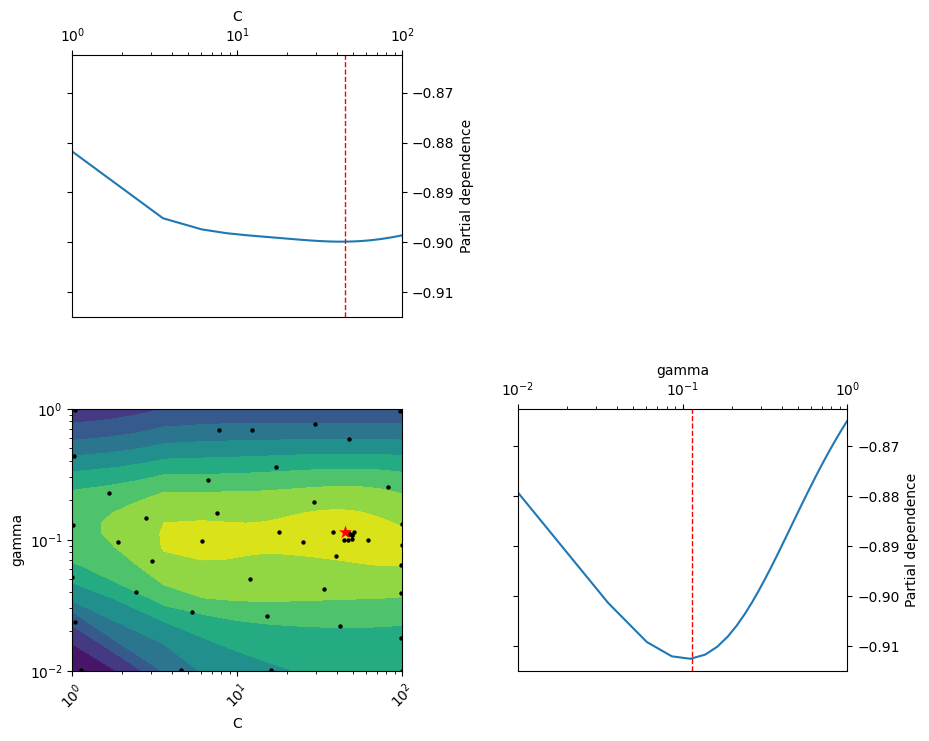

In [32]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(svc_cv.optimizer_results_[0], ax=ax)
plt.show()

In [33]:
# Train SVC
svc_tuned = SVC(kernel='rbf', **svc_cv.best_params_, 
              probability=True, random_state=random_state)

svc_tuned.fit(X_train, y_train)

SVC(C=44.72580372919008, gamma=0.11367155868632679, probability=True,
    random_state=42)

In [34]:
# Evaluate the SVC model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(svc_tuned, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the SVC model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the SVC model on the training set:
Acc: 0.8467
Pr: 0.8551
Sn: 0.8407
F1: 0.8414
MCC: 0.6949
AUROC: 0.9182


In [35]:
# Evaluate the SVC model on the test set
y_pred_svc = svc_tuned.predict(X_test)
y_proba_svc = svc_tuned.predict_proba(X_test)[:, 1]

print("Performance of the SVC model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_svc)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_svc)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_svc)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_svc)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_svc)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_svc)))

Performance of the SVC model on the test set:
Acc: 0.8342
Pr: 0.8152
Sn: 0.8643
F1: 0.8390
MCC: 0.6696
AUROC: 0.9169


#**RF**

In [36]:
# Performing Bayesian search to optimize parameters for RF
rf = RandomForestClassifier(criterion='entropy', max_features='sqrt',
                            min_samples_split=2, min_samples_leaf=1,
                            random_state=random_state)

param = {'n_estimators': (100,800), 
         'max_depth': (5,30)
        }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
rf_cv = BayesSearchCV(estimator=rf, search_spaces=param, cv=cv, scoring='roc_auc', 
                          n_jobs=-1, random_state=random_state)

start_time = time.time()
rf_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', rf_cv.best_params_)
print('best score after search cv:', rf_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('max_depth', 22), ('n_estimators', 799)])
best score after search cv: 0.9271372912075003
time taken: 0:03:15.598172


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

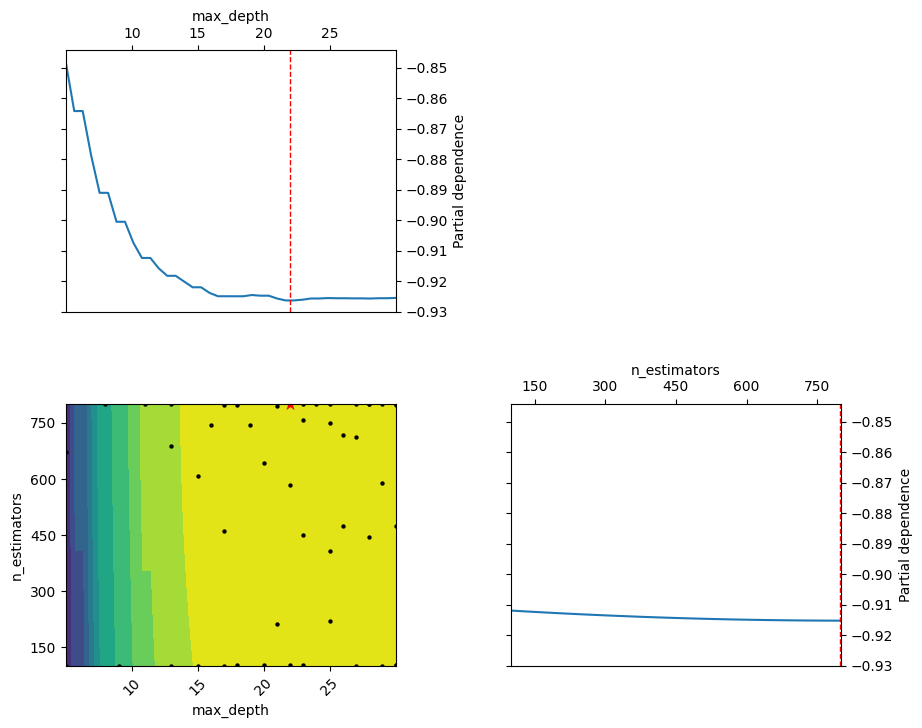

In [37]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(rf_cv.optimizer_results_[0], ax=ax)
plt.show()

In [38]:
# Train RF 
rf_tuned = RandomForestClassifier(**rf_cv.best_params_, criterion='entropy', 
                                  max_features='sqrt', min_samples_split=2, 
                                  min_samples_leaf=1, n_jobs=-1, 
                                  random_state=random_state)

rf_tuned.fit(X_train, y_train)

<IPython.core.display.Javascript object>

RandomForestClassifier(criterion='entropy', max_depth=22, n_estimators=799,
                       n_jobs=-1, random_state=42)

In [39]:
# Evaluate the RF model on the training set 
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(rf_tuned, X_train, y_train, cv=10, scoring=scoring, n_jobs=-1)

print("Performance of the RF model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the RF model on the training set:
Acc: 0.8533
Pr: 0.8435
Sn: 0.8584
F1: 0.8533
MCC: 0.7067
AUROC: 0.9260


In [40]:
# Evaluate the RF model on the test set
y_pred_rf = rf_tuned.predict(X_test)
y_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]

print("Performance of the RF model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_rf)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_rf)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_rf)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_rf)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_rf)))

Performance of the RF model on the test set:
Acc: 0.8442
Pr: 0.8408
Sn: 0.8492
F1: 0.8450
MCC: 0.6885
AUROC: 0.9183


#**XGB**

In [41]:
# Performing Bayesian search to optimize parameters for XGB
xgb = XGBClassifier(tree_method='gpu_hist', gpu_id=0, objective='binary:logistic', 
                    max_depth=20, gamma=1e-1, subsample=0.9, min_child_weight=1, 
                    colsample_bytree=1, reg_lambda=1e-2, random_state=random_state)

param = {'learning_rate': (1e-2,1, 'log-uniform'),
         'n_estimators': (200,1000)
        }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
xgb_cv = BayesSearchCV(estimator=xgb, search_spaces=param, cv=10, scoring='roc_auc',
                      random_state=random_state)

start_time = time.time()
xgb_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best paremeters: ', xgb_cv.best_params_)
print('best score after search cv:', xgb_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best paremeters:  OrderedDict([('learning_rate', 0.010124289203943317), ('n_estimators', 998)])
best score after search cv: 0.9372816279381985
time taken: 0:27:43.212316


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

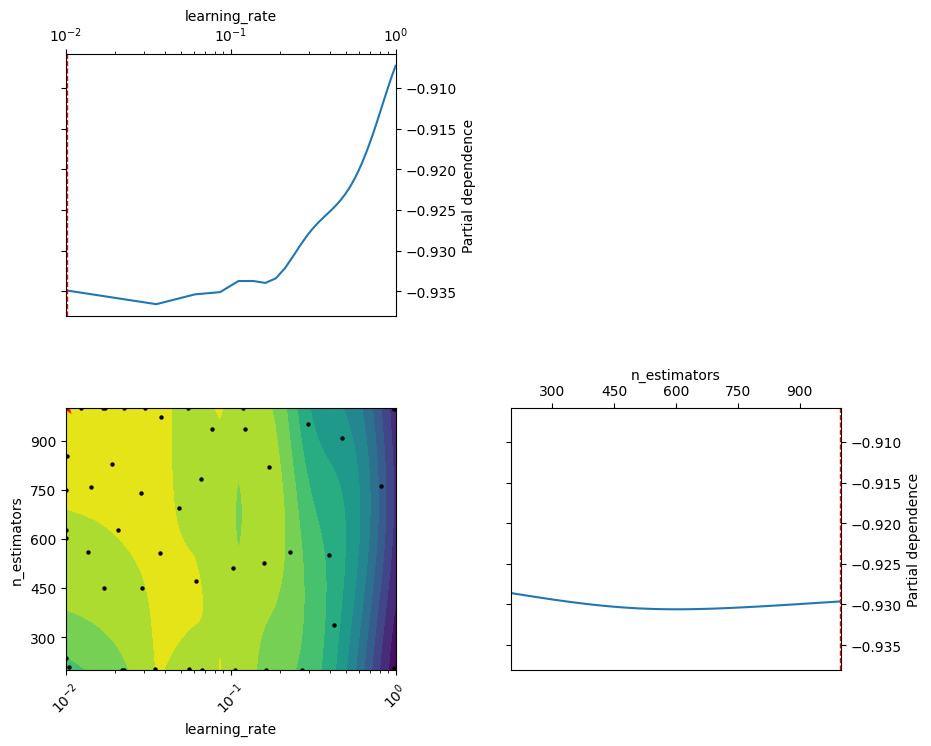

In [42]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(xgb_cv.optimizer_results_[0], ax=ax)
plt.show()

In [43]:
# Train XGB
xgb_tuned = XGBClassifier(**xgb_cv.best_params_, tree_method='gpu_hist', 
                          gpu_id=0, objective='binary:logistic', max_depth=20, 
                          gamma=1e-1, subsample=0.9, min_child_weight=1, 
                          colsample_bytree=1, reg_lambda=1e-2, random_state=random_state)

xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0.1, gpu_id=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.010124289203943317,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=20, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              n_estimators=998, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [44]:
# Evaluate the XGB model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(xgb_tuned, X_train, y_train, cv=10, scoring=scoring)

print("Performance of the XGB model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the XGB model on the training set:
Acc: 0.8578
Pr: 0.8387
Sn: 0.8889
F1: 0.8661
MCC: 0.7212
AUROC: 0.9339


In [45]:
# Evaluate the XGB model on the test set
y_pred_xgb = xgb_tuned.predict(X_test)
y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]

print("Performance of the XGB model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_xgb)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_xgb)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_xgb)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_xgb)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_xgb)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_xgb)))

Performance of the XGB model on the test set:
Acc: 0.8593
Pr: 0.8557
Sn: 0.8643
F1: 0.8600
MCC: 0.7186
AUROC: 0.9363


#**LGBM**

In [46]:
# Performing Bayesian search to optimize parameters for LGBM
lgbm = LGBMClassifier(device='gpu', objective='binary', extra_trees=True, verbose=-1, 
                      max_depth=15, min_data_in_leaf=1, bagging_freq=10, 
                      bagging_fraction=0.75, feature_fraction=1.0, reg_lambda=1e-1, 
                      num_leaves=100, random_state=random_state)

param = {'n_estimators': (100, 1000),
         'learning_rate': (5e-2,1,'log-uniform'),
        }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
lgbm_cv = BayesSearchCV(estimator=lgbm, search_spaces=param, cv=cv, scoring='roc_auc',
                       random_state=random_state)

start_time = time.time()
lgbm_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best parameters: ', lgbm_cv.best_params_)
print('best score after search cv:', lgbm_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('learning_rate', 0.05), ('n_estimators', 583)])
best score after search cv: 0.9335052526766834
time taken: 0:16:53.155712


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

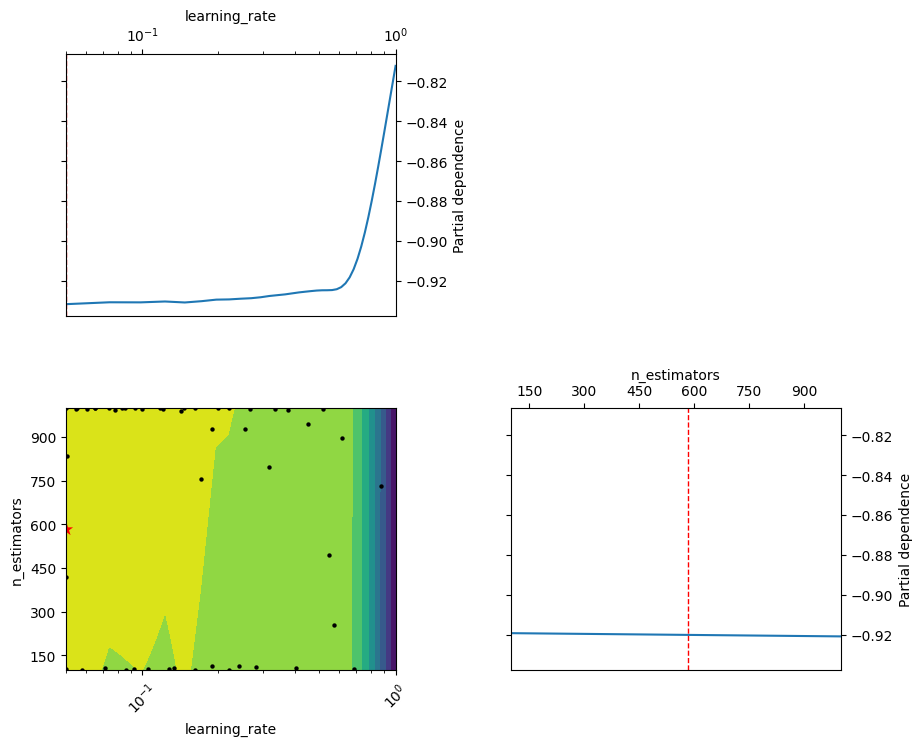

In [47]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(lgbm_cv.optimizer_results_[0], ax=ax)
plt.show()

In [48]:
# Train LGBM 
lgbm_tuned = LGBMClassifier(**lgbm_cv.best_params_, device='gpu', 
                            objective='binary', extra_trees=True,
                            verbose=-1, max_depth=15, min_data_in_leaf=1, 
                            bagging_freq=10, bagging_fraction=0.75, 
                            feature_fraction=1.0, reg_lambda=1e-1, 
                            num_leaves=100, random_state=random_state)

lgbm_tuned.fit(X_train, y_train)

LGBMClassifier(bagging_fraction=0.75, bagging_freq=10, device='gpu',
               extra_trees=True, feature_fraction=1.0, learning_rate=0.05,
               max_depth=15, min_data_in_leaf=1, n_estimators=583,
               num_leaves=100, objective='binary', random_state=42,
               reg_lambda=0.1, verbose=-1)

In [49]:
# Evaluate the LGBM model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(lgbm_tuned, X_train, y_train, cv=10, scoring=scoring)

print("Performance of the LGBM model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the LGBM model on the training set:
Acc: 0.8556
Pr: 0.8404
Sn: 0.8805
F1: 0.8578
MCC: 0.7113
AUROC: 0.9362


In [50]:
# Evaluate the LGBM model on the test set
y_pred_lgbm = lgbm_tuned.predict(X_test)
y_proba_lgbm = lgbm_tuned.predict_proba(X_test)[:, 1]

print("Performance of the LGBM model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_lgbm)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_lgbm)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_lgbm)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_lgbm)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_lgbm)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_lgbm)))

Performance of the LGBM model on the test set:
Acc: 0.8668
Pr: 0.8687
Sn: 0.8643
F1: 0.8665
MCC: 0.7337
AUROC: 0.9352


In [51]:
# Save the LGBM model
joblib.dump(lgbm_tuned, "model/lgbm.pkl")

['model/lgbm.pkl']

#**Dforest**

In [52]:
warnings.filterwarnings("ignore", category=FutureWarning)

# Performing Bayesian search to optimize parameters for deepforest
dforest = CascadeForestClassifier(use_predictor=True, predictor='forest', 
                                  criterion='entropy', n_estimators=2, 
                                  min_samples_split=2, min_samples_leaf=1, 
                                  n_jobs=-1, n_tolerant_rounds=5, verbose=0, 
                                  random_state=random_state)

param = {'n_trees': (50,1000),
         'max_depth': (5,30), 
         }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
dforest_cv = BayesSearchCV(estimator=dforest, search_spaces=param, cv=cv, 
                           n_jobs=-1, verbose=0, random_state=random_state)

start_time = time.time()
dforest_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

# Print best parameters
print('best parameters: ', dforest_cv.best_params_)
print('best score after search cv:', dforest_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

best parameters:  OrderedDict([('max_depth', 26), ('n_trees', 889)])
best score after search cv: 0.855803343166175
time taken: 1:06:53.885217


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

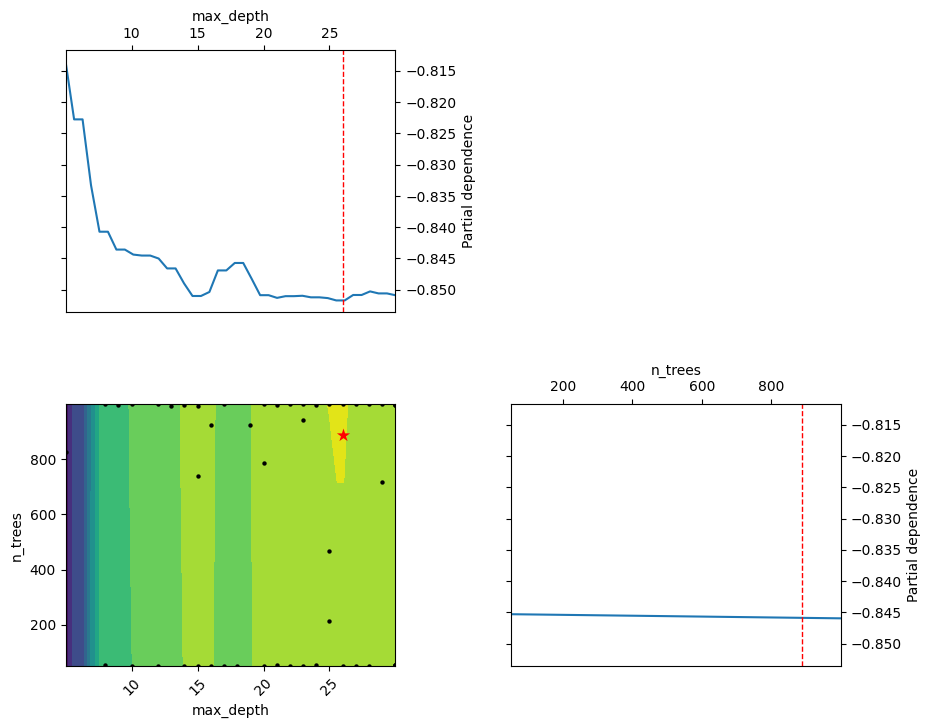

In [53]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(10, 8))
plot_objective(dforest_cv.optimizer_results_[0], ax=ax)
plt.show()

In [54]:
# Train deepforest model
dforest_tuned = CascadeForestClassifier(**dforest_cv.best_params_, use_predictor=True, 
                                        predictor='forest', criterion='entropy', n_estimators=2, 
                                        min_samples_split=2, min_samples_leaf=1, n_jobs=-1, 
                                        n_tolerant_rounds=5, verbose=0, random_state=random_state)

dforest_tuned.fit(X_train, y_train)

In [55]:
# Evaluate the deepforest model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(dforest_tuned, X_train, y_train, cv=10, verbose=0, scoring=scoring)

print("Performance of the deepforest model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 76, in _cached_call
    return cache[method]
KeyError: 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 373, in _score
    y_pred = method_caller(clf, "decision_function", X)
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 78, in _cached_call
    result = getattr(estimator, method)(*args, **kwargs)
AttributeError: 'CascadeForestClassifier' object has no attribute 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home

Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 76, in _cached_call
    return cache[method]
KeyError: 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 373, in _score
    y_pred = method_caller(clf, "decision_function", X)
  File "/home/rlsalas/miniconda3/envs/deepchem/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 78, in _cached_call
    result = getattr(estimator, method)(*args, **kwargs)
AttributeError: 'CascadeForestClassifier' object has no attribute 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the deepforest model on the training set:
Acc: 0.8489
Pr: 0.8326
Sn: 0.8628
F1: 0.8533
MCC: 0.6996
AUROC: nan


In [56]:
# Evaluate the deepforest model on the test set
y_pred_dforest = dforest_tuned.predict(X_test)
y_proba_dforest = dforest_tuned.predict_proba(X_test)[:, 1]

print("Performance of the deepforest model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_dforest)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_dforest)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_dforest)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_dforest)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_dforest)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_dforest)))

Performance of the deepforest model on the test set:
Acc: 0.8593
Pr: 0.8705
Sn: 0.8442
F1: 0.8571
MCC: 0.7189
AUROC: 0.9211


In [57]:
# Save the dforest model
joblib.dump(dforest_tuned, "model/dforest.pkl")

['model/dforest.pkl']

#**Vote**

In [58]:
# Train vote model 
vote = VotingClassifier(estimators=[('xgb', xgb_tuned), ('svc', svc_tuned)], 
                        voting='soft') 
                                          
vote.fit(X_train, y_train)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=0.1,
                                            gpu_id=0, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.01...
                                            max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=20,
                                            max_leaves=None, min_child_weight=1,
                                            missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=998, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=42, ...)),
                             ('svc',
                              SVC(C=44.72580372919008,
                                  gamma=0.11367155868632679, probability=True,
                                  random_state=42))],
                 voting='soft')

In [59]:
## Evaluate the vote model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(vote, X_train, y_train, cv=10, scoring=scoring)

print("Performance of the vote model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the vote model on the training set:
Acc: 0.8644
Pr: 0.8503
Sn: 0.8711
F1: 0.8679
MCC: 0.7317
AUROC: 0.9333


In [60]:
# Evaluate the vote model on the test set
y_pred_vote = vote.predict(X_test)
y_proba_vote = vote.predict_proba(X_test)[:, 1]

print("Performance of the vote model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_vote)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_vote)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_vote)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_vote)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_vote)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_vote)))

Performance of the vote model on the test set:
Acc: 0.8719
Pr: 0.8700
Sn: 0.8744
F1: 0.8722
MCC: 0.7437
AUROC: 0.9395


In [61]:
# Save the model
joblib.dump(vote, "model/vote_xs.pkl")

['model/vote_xs.pkl']

#**Stack**

In [62]:
# Performing Bayesian search to optimize parameters for stack final estimator
param = {'final_estimator__C': (1e-1,1e2,'log-uniform')} 

stack = StackingClassifier(estimators=[('xgb', xgb_tuned), ('svc', svc_tuned),
                                      ('logit', logit_tuned)], final_estimator=LogisticRegression(max_iter=100, 
                                      penalty='l2', solver='lbfgs'), cv=5)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
stack_cv = BayesSearchCV(estimator=stack, search_spaces=param, cv=cv, scoring='roc_auc', 
                         random_state=random_state)

start_time = time.time()
stack_cv.fit(X_train, y_train)
end_time = time.time()
time_taken = timedelta(seconds=end_time - start_time)

print('best paremeters: ', stack_cv.best_params_)
print('best estimator: ', stack_cv.best_estimator_)
print('best score after search cv:', stack_cv.best_score_)
print('time taken: {}'.format(time_taken))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best paremeters:  OrderedDict([('final_estimator__C', 73.52481813242629)])
best estimator:  StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=1,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=0.1,
                                              gpu_id=0, grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=N

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

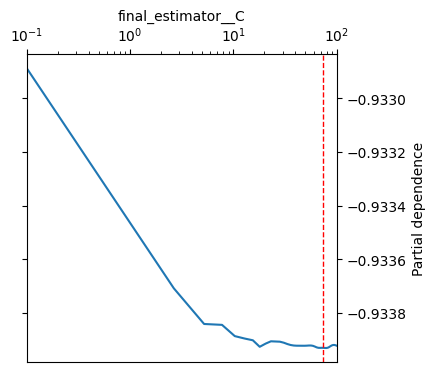

In [63]:
# Plot the Bayesian objective function
fig, ax = plt.subplots(figsize=(4, 4))
plot_objective(stack_cv.optimizer_results_[0], ax=ax)
plt.show()

In [64]:
# Train stack model 
stack = StackingClassifier(estimators=[('xgb', xgb_tuned), ('svc', svc_tuned),
                                      ('logit', logit_tuned)], final_estimator=LogisticRegression(max_iter=100, 
                                        C=73.525, penalty='l2', solver='lbfgs'), cv=5) 
                                          
stack.fit(X_train, y_train)

<IPython.core.display.Javascript object>

StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=1,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=0.1,
                                              gpu_id=0, grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_ra...
                                              min_child_weight=1, missing=nan,
                                              monotone_constraints=None,
                                              n_estimators=998, n_jobs=None,
                                              num_parallel_tree=None,
                                              predictor=None, random_state=42, ...)),
                               ('svc',
                                SVC(C=44.72580372919008,
                                    gamma=0.11367155868632679, probability=True,
                                    random_state=42)),
                               ('logit',
                                LogisticRegression(C=0.473375068822139,
                                                   max_iter=5000, n_jobs=-1,
                                                   random_state=42))],
                   final_estimator=LogisticRegression(C=73.525))

In [65]:
# Evaluate the stack model on the training set
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'matthews_corrcoef']
cv_results = cross_validate(stack, X_train, y_train, cv=10, scoring=scoring)

print("Performance of the stack model on the training set:\nAcc: {:.4f}\nPr: {:.4f}\nSn: {:.4f}\nF1: {:.4f}\nMCC: {:.4f}\nAUROC: {:.4f}".format(
    np.median(cv_results['test_accuracy']),
    np.median(cv_results['test_precision']),
    np.median(cv_results['test_recall']),
    np.median(cv_results['test_f1']),
    np.median(cv_results['test_matthews_corrcoef']),
    np.median(cv_results['test_roc_auc'])
))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance of the stack model on the training set:
Acc: 0.8622
Pr: 0.8499
Sn: 0.8622
F1: 0.8654
MCC: 0.7261
AUROC: 0.9333


In [66]:
# Evaluate the stack model on the test set
y_pred_stack = stack.predict(X_test)
y_proba_stack = stack.predict_proba(X_test)[:, 1]

print("Performance the stack model on the test set:")
print("Acc: {:.4f}".format(accuracy_score(y_test, y_pred_stack)))
print("Pr: {:.4f}".format(precision_score(y_test, y_pred_stack)))
print("Sn: {:.4f}".format(recall_score(y_test, y_pred_stack)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_stack)))
print("MCC: {:.4f}".format(matthews_corrcoef(y_test, y_pred_stack)))
print("AUROC: {:.4f}".format(roc_auc_score(y_test, y_proba_stack)))

Performance the stack model on the test set:
Acc: 0.8769
Pr: 0.8750
Sn: 0.8794
F1: 0.8772
MCC: 0.7538
AUROC: 0.9390


In [67]:
# Save the model
joblib.dump(stack, "model/stack_xsl.pkl")

['model/stack_xsl.pkl']

#**PR curves**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

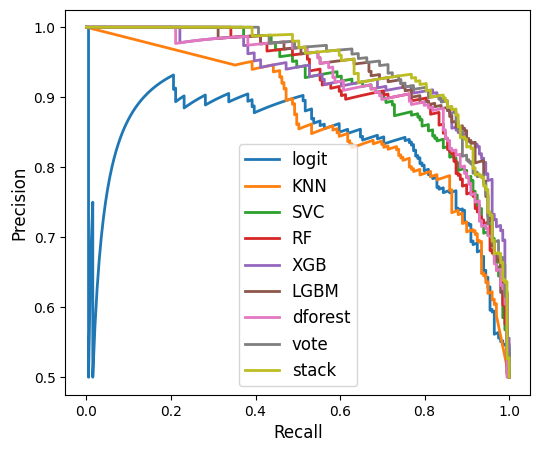

In [68]:
# Calculate decision function or probabilities for each model
y_thres_logit = logit_tuned.decision_function(X_test)
y_proba_knn = knn_tuned.predict_proba(X_test)[:, 1]
y_thres_svc = svc_tuned.decision_function(X_test)
y_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
y_proba_lgbm = lgbm_tuned.predict_proba(X_test)[:, 1]
y_proba_dforest = dforest_tuned.predict_proba(X_test)[:, 1]
y_proba_vote = vote.predict_proba(X_test)[:, 1]
y_proba_stack = stack.predict_proba(X_test)[:, 1]

# Calculate precision and recall for each model
precision_logit, recall_logit, _ = precision_recall_curve(y_test, y_thres_logit)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_proba_knn)
precision_svc, recall_svc, _ = precision_recall_curve(y_test, y_thres_svc)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_proba_lgbm)
precision_dforest, recall_dforest, _ = precision_recall_curve(y_test, y_proba_dforest)
precision_vote, recall_vote, _ = precision_recall_curve(y_test, y_proba_vote)
precision_stack, recall_stack, _ = precision_recall_curve(y_test, y_proba_stack)

# Function to plot precision-recall curve
def plot_PR_curve(precision, recall, label=None):
    plt.plot(recall, precision, linewidth=2, label=label)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel('Precision', fontsize=12)
    plt.xlabel('Recall', fontsize=12)
    plt.grid(False)

# Plot PR curves for all models
plt.figure(figsize=(6, 5))
plot_PR_curve(precision_logit, recall_logit, "logit")
plot_PR_curve(precision_knn, recall_knn, "KNN")
plot_PR_curve(precision_svc, recall_svc, "SVC")
plot_PR_curve(precision_rf, recall_rf, "RF")
plot_PR_curve(precision_xgb, recall_xgb, "XGB")
plot_PR_curve(precision_lgbm, recall_lgbm, "LGBM")
plot_PR_curve(precision_dforest, recall_dforest, "dforest")
plot_PR_curve(precision_vote, recall_vote, "vote")
plot_PR_curve(precision_stack, recall_stack, "stack")

plt.legend(loc="best", fontsize=12)
plt.show()

#**ROC curves**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

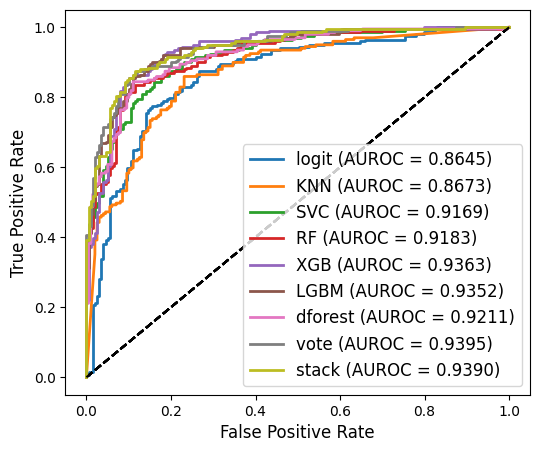

In [70]:
# Calculate ROC curves and AUC for each model
fpr, tpr, thresholds = roc_curve(y_test, y_thres_logit)
auroc = auc(fpr, tpr)

fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_proba_knn)
auroc_knn = auc(fpr_knn, tpr_knn)

fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_thres_svc)
auroc_svc = auc(fpr_svc, tpr_svc)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
auroc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)
auroc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(y_test, y_proba_lgbm)
auroc_lgbm = auc(fpr_lgbm, tpr_lgbm)

fpr_dforest, tpr_dforest, thresholds_dforest = roc_curve(y_test, y_proba_dforest)
auroc_dforest = auc(fpr_dforest, tpr_dforest)

fpr_vote, tpr_vote, thresholds_vote = roc_curve(y_test, y_proba_vote)
auroc_vote = auc(fpr_vote, tpr_vote)

fpr_stack, tpr_stack, thresholds_stack = roc_curve(y_test, y_proba_stack)
auroc_stack = auc(fpr_stack, tpr_stack)

# Define a function to plot the ROC curve
def plot_roc_curve(fpr, tpr, auroc, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=f'{label} (AUROC = {auroc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.grid(False)

# Plot all ROC curves
plt.figure(figsize=(6, 5))
plot_roc_curve(fpr, tpr, auroc, "logit")
plot_roc_curve(fpr_knn, tpr_knn, auroc_knn, "KNN")
plot_roc_curve(fpr_svc, tpr_svc, auroc_svc, "SVC")
plot_roc_curve(fpr_rf, tpr_rf, auroc_rf, "RF")
plot_roc_curve(fpr_xgb, tpr_xgb, auroc_xgb, "XGB")
plot_roc_curve(fpr_lgbm, tpr_lgbm, auroc_lgbm, "LGBM")
plot_roc_curve(fpr_dforest, tpr_dforest, auroc_dforest, "dforest")
plot_roc_curve(fpr_vote, tpr_vote, auroc_vote, "vote")
plot_roc_curve(fpr_stack, tpr_stack, auroc_stack, "stack")

plt.legend(loc="best", fontsize=12)
plt.savefig('Eco_roc.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#**Evaluation**

In [71]:
# Print classification report for xgb
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       199
           1       0.86      0.86      0.86       199

    accuracy                           0.86       398
   macro avg       0.86      0.86      0.86       398
weighted avg       0.86      0.86      0.86       398



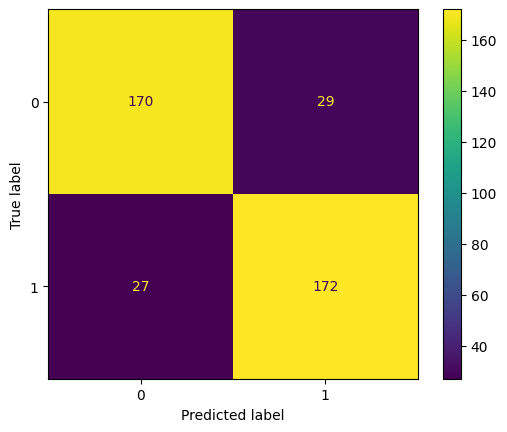

In [72]:
# Plot confusion matrix for xgb model
cm = confusion_matrix(y_test, y_pred_xgb, labels=xgb_tuned.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_tuned.classes_)
disp.plot()

In [73]:
# Visualize observations that were incorrectly labeled
Flabel = pd.DataFrame(X_test[y_test != y_pred_xgb])
Flabel

<IPython.core.display.Javascript object>

,Q,frac_CC,ECFP0,ECFP1,ECFP2,ECFP3,ECFP4,ECFP5,ECFP6,ECFP7,...,ECFP1014,ECFP1015,ECFP1016,ECFP1017,ECFP1018,ECFP1019,ECFP1020,ECFP1021,ECFP1022,ECFP1023
1985,0.423077,0.618852,0.314815,0.394737,0.333333,0.083333,0.760870,0.25,0.05,0.0,...,0.000000,0.25,0.40625,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00
504,0.346154,0.297600,0.611111,0.789474,0.561404,0.083333,0.032609,0.05,0.05,0.0,...,0.000000,0.05,0.75000,0.1,0.0,0.000000,0.000000,0.000000,0.0,0.00
1069,0.346154,0.421472,0.191358,0.210526,0.175439,0.333333,0.347826,0.00,0.20,0.0,...,0.000000,0.20,0.18750,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00
590,0.346154,0.470628,0.160494,0.184211,0.210526,0.000000,0.347826,0.20,0.00,0.0,...,0.000000,0.20,0.18750,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00
914,0.461538,0.221729,0.456790,0.526316,0.421053,0.333333,0.195652,0.00,0.00,0.0,...,0.000000,0.00,0.53125,0.1,0.0,0.000000,0.000000,0.222222,0.5,0.00
1991,0.307692,0.466078,0.370370,0.394737,0.315789,0.083333,0.108696,0.05,0.15,0.0,...,0.000000,0.10,0.37500,0.1,0.0,0.000000,0.000000,0.000000,0.0,0.00
2025,0.384615,0.381569,0.185185,0.236842,0.210526,0.000000,0.260870,0.15,0.00,0.0,...,0.000000,0.15,0.21875,0.0,0.0,0.333333,0.000000,0.000000,0.0,0.00
639,0.269231,0.426481,0.333333,0.421053,0.315789,0.083333,0.065217,0.00,0.00,0.0,...,0.000000,0.00,0.40625,0.1,0.0,0.000000,0.000000,0.000000,0.0,0.00
237,0.423077,0.043076,0.419753,0.473684,0.526316,0.083333,0.000000,0.00,0.00,0.0,...,0.000000,0.00,0.46875,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.50
1137,0.423077,0.433013,0.524691,0.552632,0.491228,0.083333,0.141304,0.05,0.00,0.0,...,0.333333,0.00,0.59375,0.1,0.0,0.000000,0.000000,0.111111,1.0,0.00


#**Feature importance**

In [74]:
# Find shap values
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

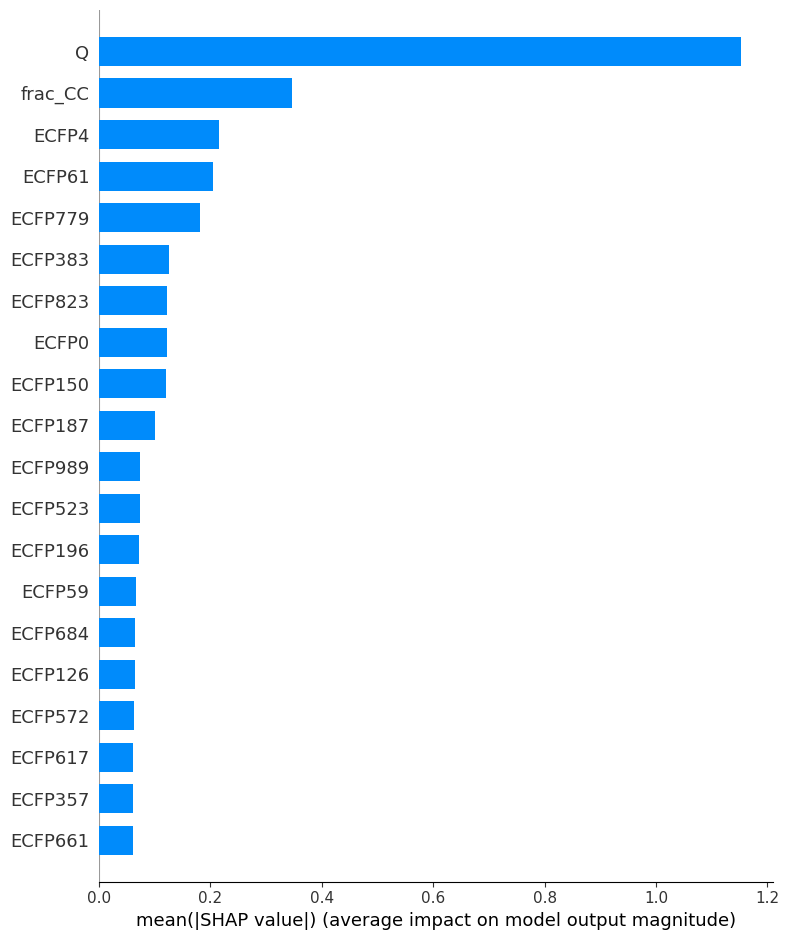

In [75]:
# Bar plot of shap values for class 1
shap.summary_plot(shap_values, X_test, plot_type='bar')

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


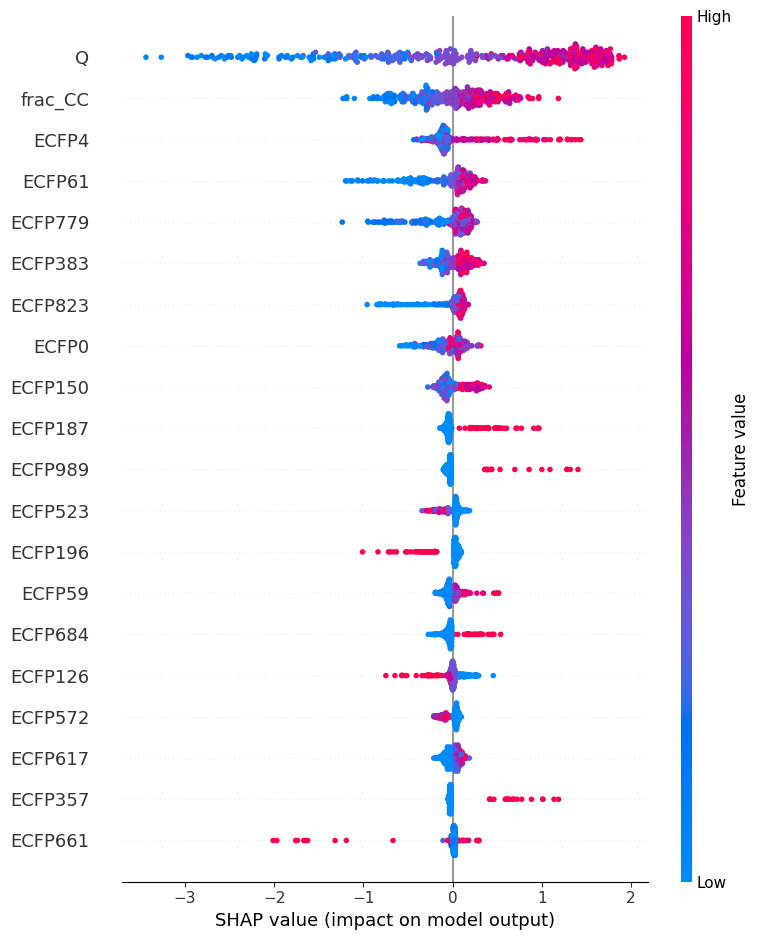

In [76]:
# Beeswarm plot of shap values
shap.summary_plot(shap_values, X_test)